In [4]:
# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)



In [5]:

# EDA from week2 Mod B
df_diabetes = pd.read_csv("diabetes_binary_health_indicators_BRFSS2015.csv")
df_ckd = pd.read_csv("Chronic_Kidney_Dsease_data.csv")
df_hypertension = pd.read_csv("hypertension_dataset.csv")
df_alzheimers = pd.read_csv("alzheimers_disease_data.csv")

# Generate basic summaries
diabetes_desc = df_diabetes.describe(include='all')
ckd_desc = df_ckd.describe(include='all')
hypertension_desc = df_hypertension.describe(include='all')
alzheimers_desc = df_alzheimers.describe(include='all')

# Check for duplicates
diabetes_duplicates = df_diabetes.duplicated().sum()
ckd_duplicates = df_ckd.duplicated().sum()
alzheimers_duplicates = df_alzheimers.duplicated().sum()
_duplicates = df_hypertension.duplicated().sum()
# Check for nulls
diabetes_nulls = df_diabetes.isnull().sum()
ckd_nulls = df_ckd.isnull().sum()
hypertension_nulls = df_hypertension.isnull().sum()
alzheimers__nulls = df_alzheimers.isnull().sum()

# Display descriptive summaries

print("\n===alzheimers-Summary ===")
print(ckd_desc)
# Return duplicates and total null values per dataset
print("\n=== Duplicates in alzheimers_duplicates Dataset ===")
print(f"alzheimers: {alzheimers_duplicates}")

# Return nulls
print("\n=== Total Null Values in alzheimers Dataset ===")
print(f"Diabealzheimerstes: {alzheimers__nulls.sum()}")


#Diabetes Dataset
#Duplicates: 24,206 rows — significant duplication, should be reviewed or removed
#Missing values: None
#Usability: Usable after deduplication

#Chronic Kidney Disease (CKD) Dataset
#Duplicates: None
#Missing values: None\
#Usability: Clean and ready for analysis

#Hypertension Dataset
#Duplicates: None
#Missing values: None
#Usability: Ready to use

# Steps to clean up Diabetes Dataset 
#Remove duplicates from the diabetes dataset: df_diabetes.drop_duplicates(inplace=True)
#Consider class balance checks (e.g., ratio of positive to negative labels)
#Identify categorical features and apply encoding (pd.get_dummies or OrdinalEncoder)
#Explore mode, median, and outliers for inconsistent data (e.g., age = 0)

#1 Remove Duplicates
df_diabetes.drop_duplicates(inplace=True)
#2 Handling any missing values
df_diabetes.fillna(df_diabetes.median(), inplace=True)  # For numeric columns
df_diabetes.fillna("Unknown", inplace=True)    # For categorical columns
#3Check for Inconsistencies
  #Negative ages or values outside expected range
  #Incorrect data types (e.g., numeric coded as string)
#4 Check for Class Imbalance

print(df_diabetes['Diabetes_binary'].value_counts(normalize=True))
print(df_hypertension['Hypertension'].value_counts(normalize=True))
#print(df_ckd['classification'].value_counts(normalize=True)) 

# Encode Categorical Variables
# One-hot encoding (for logistic regression, tree-based models)
df = pd.get_dummies(df_diabetes, drop_first=True)

# Or ordinal encoding if there is a natural order
#print("Arun")
#print(df_ckd.columns)
categorical_cols = df_ckd.select_dtypes(include=['object', 'category']).columns.tolist()
#print("Categorical columns:", categorical_cols)

from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
df_ckd[['DoctorInCharge']] = encoder.fit_transform(df_ckd[['DoctorInCharge']])




===alzheimers-Summary ===
          PatientID          Age       Gender   Ethnicity  \
count   1659.000000  1659.000000  1659.000000  1659.00000   
unique          NaN          NaN          NaN         NaN   
top             NaN          NaN          NaN         NaN   
freq            NaN          NaN          NaN         NaN   
mean     830.000000    54.441230     0.515371     0.71308   
std      479.056364    20.549757     0.499914     1.00043   
min        1.000000    20.000000     0.000000     0.00000   
25%      415.500000    36.000000     0.000000     0.00000   
50%      830.000000    54.000000     1.000000     0.00000   
75%     1244.500000    72.000000     1.000000     1.00000   
max     1659.000000    90.000000     1.000000     3.00000   

        SocioeconomicStatus  EducationLevel          BMI      Smoking  \
count           1659.000000     1659.000000  1659.000000  1659.000000   
unique                  NaN             NaN          NaN          NaN   
top                  

Best params: {'clf__metric': 'minkowski', 'clf__n_neighbors': 75, 'clf__p': 1, 'clf__weights': 'distance'}
CV ROC-AUC: 0.709
Validation ROC-AUC: 0.672 | PR-AUC: 0.902 | Brier: 0.148
Chosen threshold (Youden’s J, from validation): 0.843
Test ROC-AUC: 0.748 | PR-AUC: 0.933 | Brier: 0.141
Confusion matrix (test):
 [[ 73  10]
 [161 186]]

Classification report (test):
               precision    recall  f1-score   support

           0      0.312     0.880     0.461        83
           1      0.949     0.536     0.685       347

    accuracy                          0.602       430
   macro avg      0.630     0.708     0.573       430
weighted avg      0.826     0.602     0.642       430



/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


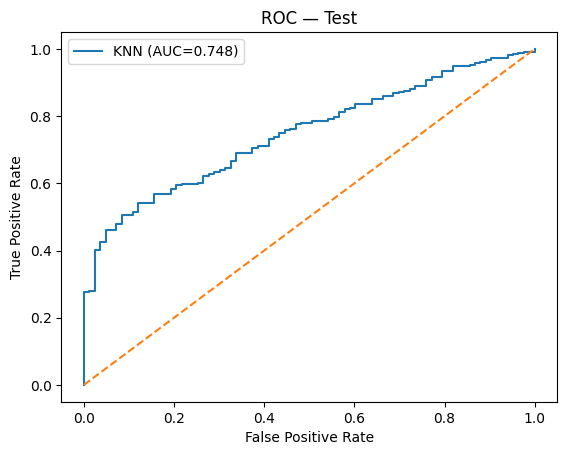

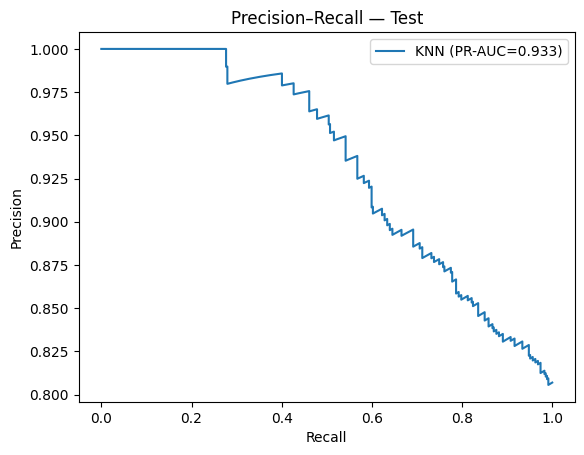

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimato

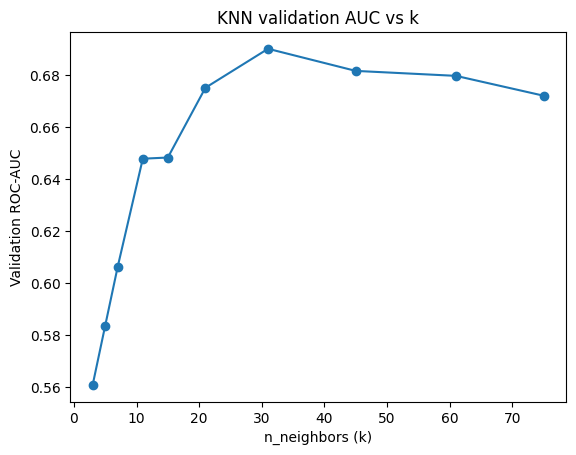

In [6]:
df=df_alzheimers
target_col = "MMSE"  
# Drop obvious IDs / admin fields if present
for c in ["PatientID","patient_id","ID","Id","DoctorInCharge"]:
    if c in df.columns:
        df.drop(columns=c, inplace=True)

assert "MMSE" in df.columns, "MMSE column not found in dataset."
df = df.dropna(subset=["MMSE"]).copy()

# Binary target: Impaired if MMSE < 24
df["Impaired"] = (df["MMSE"] < 24).astype(int)

# Prevent leakage: drop MMSE from features
y = df["Impaired"].values
X = df.drop(columns=["Impaired","MMSE"])

# Train/validation/test split (60/20/20), stratified on the binary target
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)  # 0.6 / 0.2 / 0.2

# === 2) Preprocessing (inside the pipeline)
cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if c not in cat_cols]

# Handle OneHotEncoder API differences across sklearn versions
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    # older sklearn
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imp", SimpleImputer(strategy="median")),
            ("sc",  StandardScaler())
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("oh",  ohe)
        ]), cat_cols)
    ],
    remainder="drop"
)

# === 3) KNN model + CV grid
knn = KNeighborsClassifier()

pipe = Pipeline(steps=[
    ("pre", pre),
    ("clf", knn)
])

# Bias-variance & metric grid:
# - n_neighbors: odd values to avoid ties
# - weights: uniform vs distance
# - metric/p: Minkowski with p=1 (L1) or p=2 (L2)
param_grid = {
    "clf__n_neighbors": [3, 5, 7, 11, 15, 21, 31, 45, 61, 75],
    "clf__weights": ["uniform", "distance"],
    "clf__metric": ["minkowski"],
    "clf__p": [1, 2]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="roc_auc",          # primary model-selection metric
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=0
)

gs.fit(X_train, y_train)
print("Best params:", gs.best_params_)
print("CV ROC-AUC:", round(gs.best_score_, 4))

# === 4) Validate calibration/threshold on the held-out val set
best = gs.best_estimator_

# KNN has predict_proba; optional: calibration to improve probability quality
cal = CalibratedClassifierCV(best, method="sigmoid", cv="prefit")
cal.fit(X_val, y_val)

p_val = cal.predict_proba(X_val)[:, 1]
p_test = cal.predict_proba(X_test)[:, 1]

# Validation metrics
val_roc = roc_auc_score(y_val, p_val)
val_pr  = average_precision_score(y_val, p_val)
val_brier = brier_score_loss(y_val, p_val)
print(f"Validation ROC-AUC: {val_roc:.3f} | PR-AUC: {val_pr:.3f} | Brier: {val_brier:.3f}")

# === 5) Choose operating threshold on validation, then freeze
fpr_v, tpr_v, thr_v = roc_curve(y_val, p_val)
youden = tpr_v - fpr_v
thr_star = thr_v[np.argmax(youden)]
print(f"Chosen threshold (Youden’s J, from validation): {thr_star:.3f}")

# === 6) Evaluate on test (with frozen threshold)
test_roc = roc_auc_score(y_test, p_test)
test_pr  = average_precision_score(y_test, p_test)
test_brier = brier_score_loss(y_test, p_test)
print(f"Test ROC-AUC: {test_roc:.3f} | PR-AUC: {test_pr:.3f} | Brier: {test_brier:.3f}")

yhat_test = (p_test >= thr_star).astype(int)
print("Confusion matrix (test):\n", confusion_matrix(y_test, yhat_test))
print("\nClassification report (test):\n", classification_report(y_test, yhat_test, digits=3))

# === 7) Curves
# ROC
fpr_t, tpr_t, _ = roc_curve(y_test, p_test)
plt.figure()
plt.plot(fpr_t, tpr_t, label=f"KNN (AUC={test_roc:.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Test")
plt.legend()
plt.show()

# Precision–Recall
pr_t, rc_t, _ = precision_recall_curve(y_test, p_test)
plt.figure()
plt.plot(rc_t, pr_t, label=f"KNN (PR-AUC={test_pr:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall — Test")
plt.legend()
plt.show()

# === 8) (Optional) quick ablation: show how performance changes with k
# Handy to visualize the bias–variance trade-off
k_vals = [3, 5, 7, 11, 15, 21, 31, 45, 61, 75]
val_auc_by_k = []
for k in k_vals:
    tmp = Pipeline(steps=[
        ("pre", pre),
        ("clf", KNeighborsClassifier(
            n_neighbors=k,
            weights=gs.best_params_["clf__weights"],
            metric="minkowski",
            p=gs.best_params_["clf__p"]
        ))
    ])
    tmp.fit(X_train, y_train)
    tmp_cal = CalibratedClassifierCV(tmp, method="sigmoid", cv="prefit")
    tmp_cal.fit(X_val, y_val)
    pv = tmp_cal.predict_proba(X_val)[:,1]
    val_auc_by_k.append(roc_auc_score(y_val, pv))

plt.figure()
plt.plot(k_vals, val_auc_by_k, marker="o")
plt.xlabel("n_neighbors (k)")
plt.ylabel("Validation ROC-AUC")
plt.title("KNN validation AUC vs k")
plt.show()


All preprocessing is inside the pipeline → no data leakage during CV.

Grid tunes the core KNN knobs: n_neighbors (bias–variance), weights (uniform vs distance), and p (L1 vs L2).

We calibrate on the validation split and pick a threshold there; test metrics are then computed with that frozen threshold. This mirrors how you’d deploy the model.